In [1]:
# Presentation:
# - Multi-Object

In [2]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

In [3]:
from classes.particle_filter import ParticleFilter
from classes.particle_filter_multiple import MultiObjectParticleFilter
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import create_ground_truth, generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particles_at_time, animate_particle_filter, plot_particle_filter_step
from classes.evaluator import get_stats
from classes.tester import create_test_scenario, ParticleFilterTester, run_one_test
import numpy as np

/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:51: SyntaxWarning: invalid escape sequence '\s'
  w_t^i = \frac{w_t^i}{\sum_jw_t^j}
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:69: SyntaxWarning: invalid escape sequence '\d'
  p(q_t|<o>_t) /approx SUM_i(w_t^i*\delta*(s_t^i - q_t))
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:284: SyntaxWarning: invalid escape sequence '\e'
  In Our case: Physics Model with noise: q_t = A_t q_{t-1} + B_t q_{t-1} + \epsilon_t
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:295: SyntaxWarning: invalid escape sequence '\s'
  Normalization (reassure weights sum up to 1): w_t^i = \frac{w_t^i}{\sum_jw_t^j}


In [ ]:
seed = 5

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]

# Simulation Parameters
dropout_start = 40
dropout_end = 60
process_noise = 2.0#2.0
measurement_noise = 9.0#9.0

# A LOT of balls:
true_states = generate_random_balls(num_balls=3, state_bounds=STATE_BOUNDS)
true_states = np.array([[50.0, 50.0, 15.0, 25.0], [10.0, 10.0, 12.0, 30.0], [20.0, 20.0, 30.0, 3.0]], dtype=float)

n_objects = len(true_states)

# Particle Filter Parameters
num_particles_per_ball = 3000

input_parameters = {
    # Parameters for the simulation
    "step_size": 0.9,
    "num_steps": 10,

    # Parameters for the balls
    "true_states": true_states,
    "dropout_start": 40,
    "dropout_end": 60,
    "process_noise": 1e-2,#9.0, # Since we copy particles when resampling, process noise spreads them out in an area to make particles more diverse.
    "measurement_noise": 1e-2,#25.0,

    # Parameters for the Filter
    "model": "SingleParticleFilter", # Either "MultiObjectParticleFilter" or "SingleObjectParticleFilter"

    "num_particles": 1_000, # For Multi-Object Particle Filter, this is the number of particles PER BALL
    "state_bounds": STATE_BOUNDS, 
    "init_generator": "Sobol", # Either "Sobol", "LHS", or "PseudoRandom"

    'ess_resample_threshold': np.inf, # Always resample

    "logs": ["PF", "GMM"]
}

tester = ParticleFilterTester(input_parameters, save_dir="results")
results = tester.run()
#results
#results = tester.sweep_multi({
    #"use_velocity_likelihood": [True, False],
#}, mode="grid", seed=seed)
#results

Exec ParticleFilter with 1000 Particles and 3 balls. change_resample_order = True
Normalizing weights sum of  0.0
Resampling - Var 1


/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:58: RuntimeWarning: invalid value encountered in scalar divide
  p.weight /= total_weight
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:51: SyntaxWarning: invalid escape sequence '\s'
  w_t^i = \frac{w_t^i}{\sum_jw_t^j}
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:69: SyntaxWarning: invalid escape sequence '\d'
  p(q_t|<o>_t) /approx SUM_i(w_t^i*\delta*(s_t^i - q_t))
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:285: SyntaxWarning: invalid escape sequence '\e'
  In Our case: Physics Model with noise: q_t = A_t q_{t-1} + B_t q_{t-1} + \epsilon_t
/Users/Peter/MAI/Semester_1/RL/portfolios/Portfolio02_ParticleFilter/particle_filter/classes/particle_filter.py:296: SyntaxWarning: invali

ValueError: probabilities contain NaN

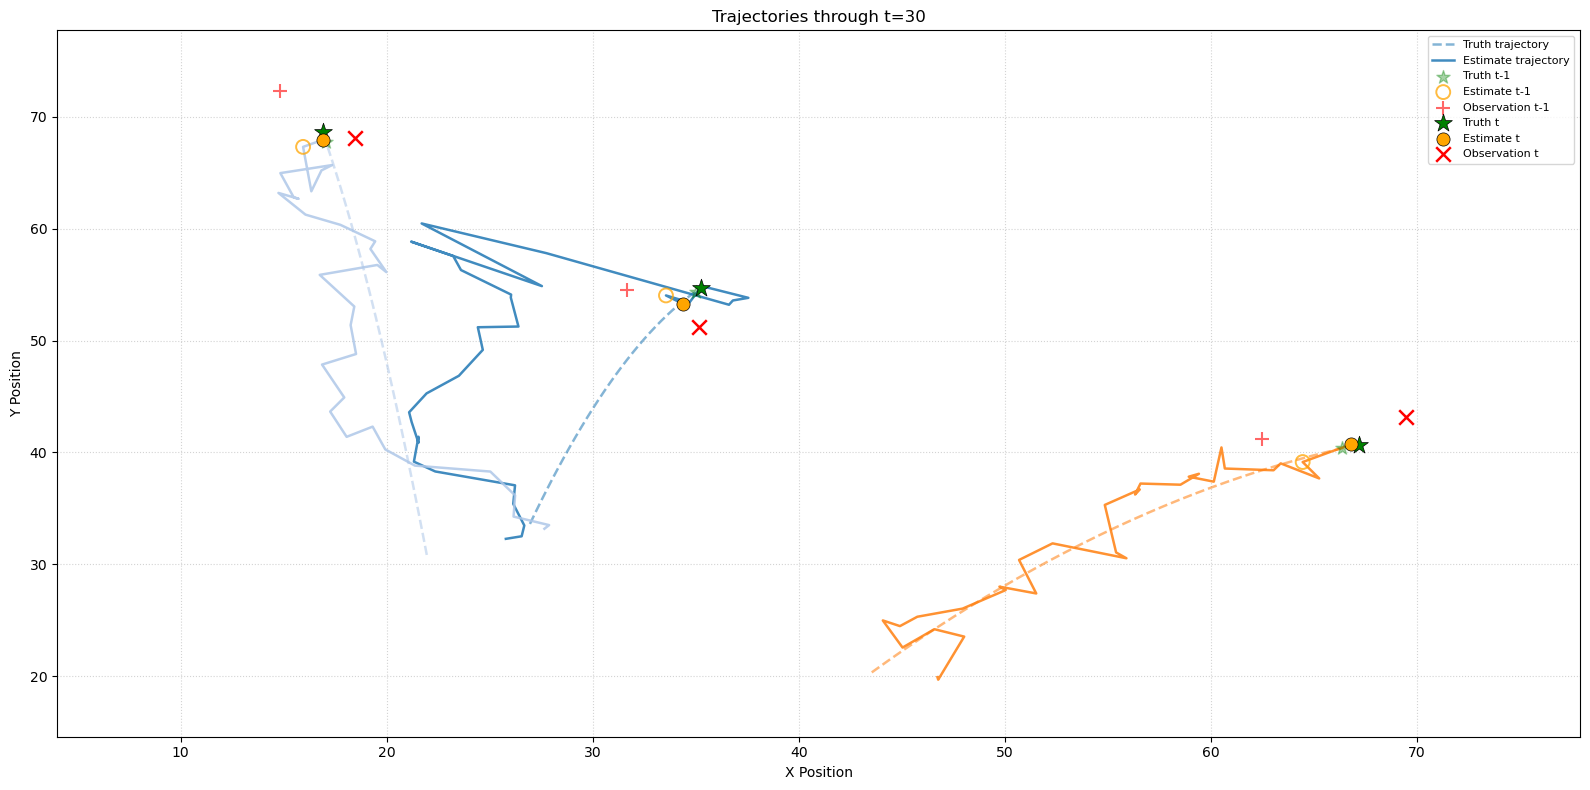

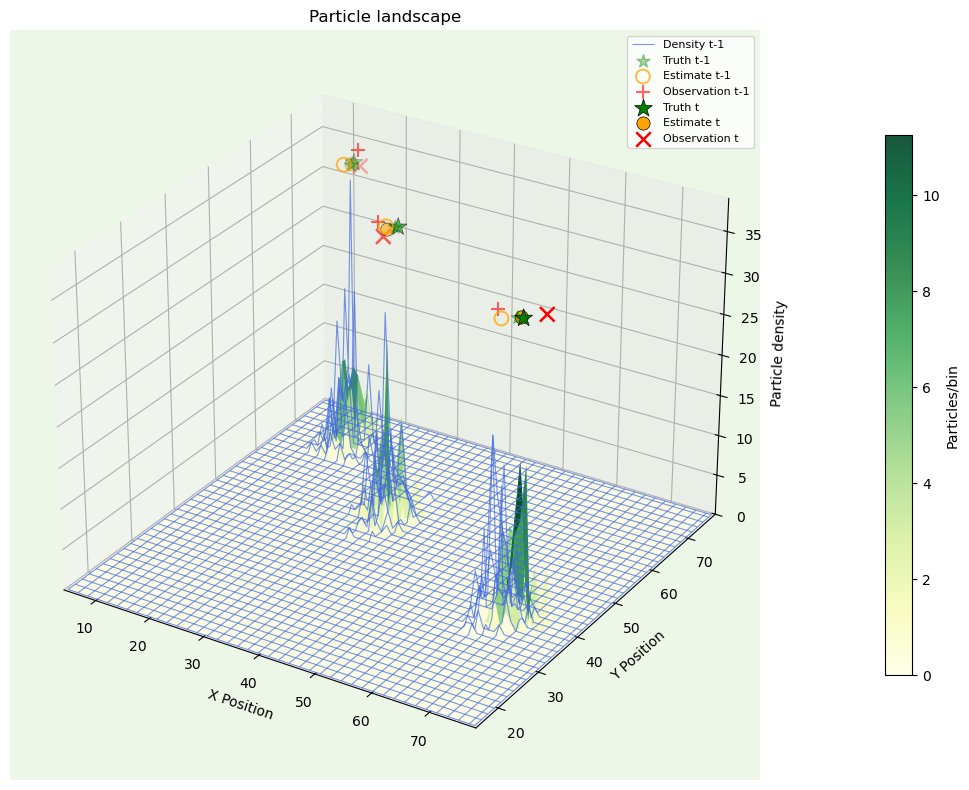

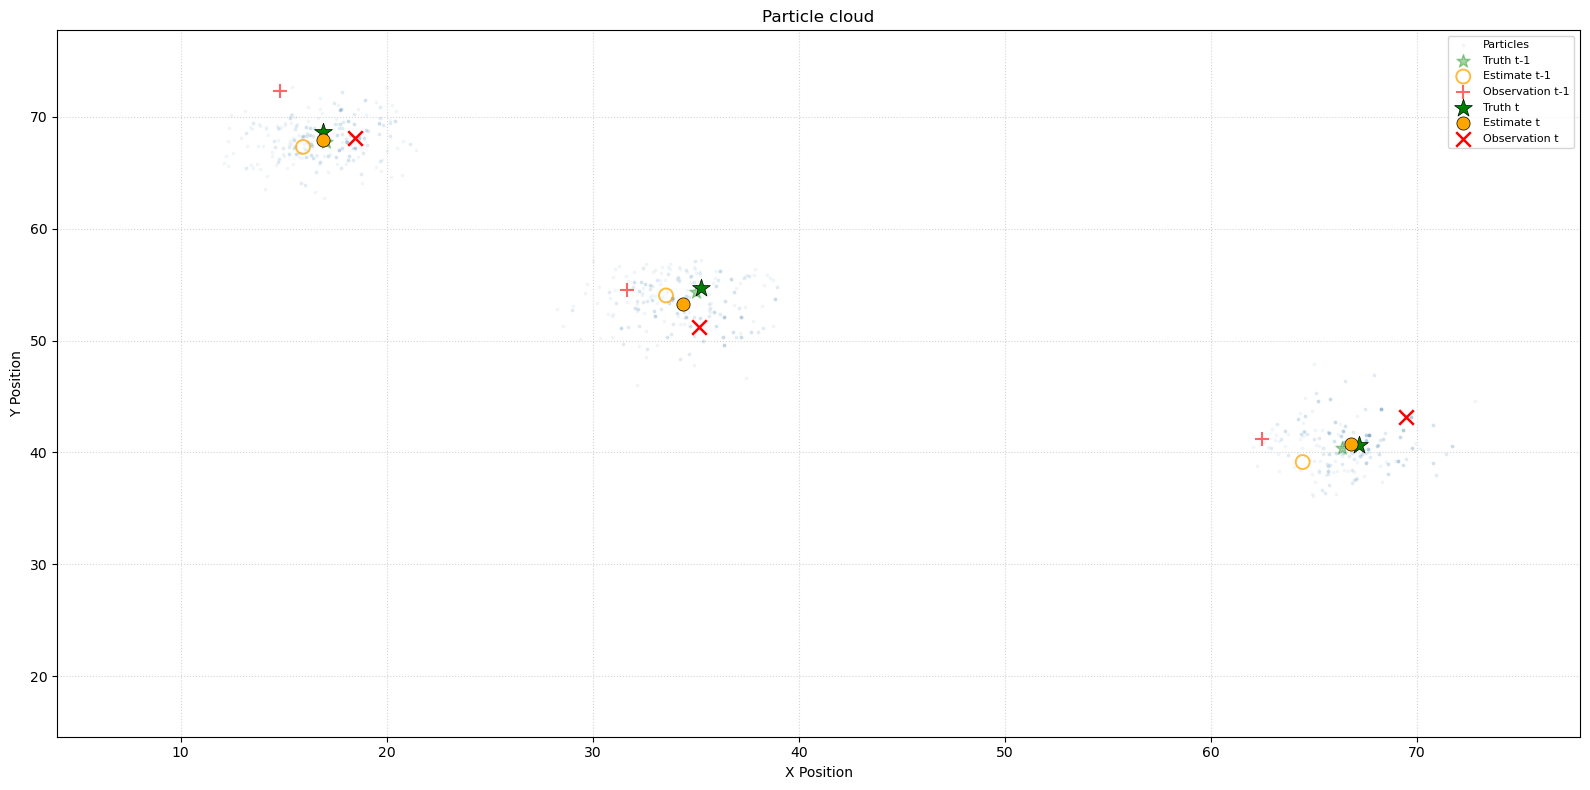

((<Figure size 1600x800 with 1 Axes>,
  <Figure size 1600x800 with 2 Axes>,
  <Figure size 1600x800 with 1 Axes>),
 (<Axes: title={'center': 'Trajectories through t=30'}, xlabel='X Position', ylabel='Y Position'>,
  <Axes3D: title={'center': 'Particle landscape'}, xlabel='X Position', ylabel='Y Position', zlabel='Particle density'>,
  <Axes: title={'center': 'Particle cloud'}, xlabel='X Position', ylabel='Y Position'>))

In [5]:
plot_particle_filter_step(time=30, **results["raw"])